In [2]:
"""
Exploratory Data Analysis (EDA) - Diwali Festive Sales Performance
Author: [Your Name]
Description: Primary data ingestion, environment configuration, and integrity verification.
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure inline plotting and high-resolution figure rendering
%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
sns.set_theme(style="whitegrid")

def load_sales_dataset(file_path: str) -> pd.DataFrame:
    """
    Ingests the primary sales dataset with appropriate character encoding error handling.
    """
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Target data file asset '{file_path}' could not be located in the current workspace.")

    try:
        data_frame = pd.read_csv(file_path, encoding='unicode_escape')
        print(f"Success: Dataset loaded successfully. Shape: {data_frame.shape[0]} rows, {data_frame.shape[1]} columns.")
        return data_frame
    except Exception as error:
        print(f"Execution Error during data ingestion: {str(error)}")
        return pd.DataFrame()

# Execute ingestion pipeline
DATA_FILE = 'Diwali Sales Data.csv'
df = load_sales_dataset(DATA_FILE)

# Inspect structural attributes and schema characteristics
df.head()

Success: Dataset loaded successfully. Shape: 11251 rows, 15 columns.


,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [7]:

"""
Data Cleaning and Preprocessing Pipeline
Description: Drops redundant structures, rectifies null matrices, corrects data types, and exports the clean baseline.
"""

# 1. Structural Verification: Inspect initial columns and missing value counts
print("Initial Missing Values Profile:")
print(df.isnull().sum())
print("\n" + "="*50 + "\n")
# 2. Drop Redundant/Empty Columns (Commonly 'Status' and 'unnamed1' if present)
# We safely drop them if they exist in the current schema
columns_to_drop = ['Status', 'unnamed1']
df.drop(columns=[col for col in columns_to_drop if col in df.columns], axis=1, inplace=True)
# 3. Handle Null Values
# Inspect the 'Amount' column or other critical fields for missing values and drop records
df.dropna(inplace=True)
# 4. Data Type Conversion
# Convert 'Amount' from float/object to integer for accurate quantitative analysis
if 'Amount' in df.columns:
    df['Amount'] = df['Amount'].astype(int)
# 5. Operational Consistency: Remove duplicate rows to ensure statistical accuracy
duplicate_count = df.duplicated().sum()
df.drop_duplicates(inplace=True)
print(f"Data Cleaning Completed:\n- Duplicates removed: {duplicate_count}\n- Final matrix shape: {df.shape[0]} rows, {df.shape[1]} columns.")
# 6. Export Purified Dataset to CSV
OUTPUT_FILE = 'diwali_cleaned.csv'
df.to_csv(OUTPUT_FILE, index=False)
print(f" Cleaned dataset successfully exported as '{OUTPUT_FILE}'")
# Preview structural schema post-cleaning
df.info()


Initial Missing Values Profile:
User_ID             0
Cust_name           0
Product_ID          0
Gender              0
Age Group           0
Age                 0
Marital_Status      0
State               0
Zone                0
Occupation          0
Product_Category    0
Orders              0
Amount              0
dtype: int64


Data Cleaning Completed:
- Duplicates removed: 0
- Final matrix shape: 11231 rows, 13 columns.
 Cleaned dataset successfully exported as 'diwali_cleaned.csv'
<class 'pandas.core.frame.DataFrame'>
Index: 11231 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   User_ID           11231 non-null  int64 
 1   Cust_name         11231 non-null  object
 2   Product_ID        11231 non-null  object
 3   Gender            11231 non-null  object
 4   Age Group         11231 non-null  object
 5   Age               11231 non-null  int64 
 6   Marital_Status    11231 non-null

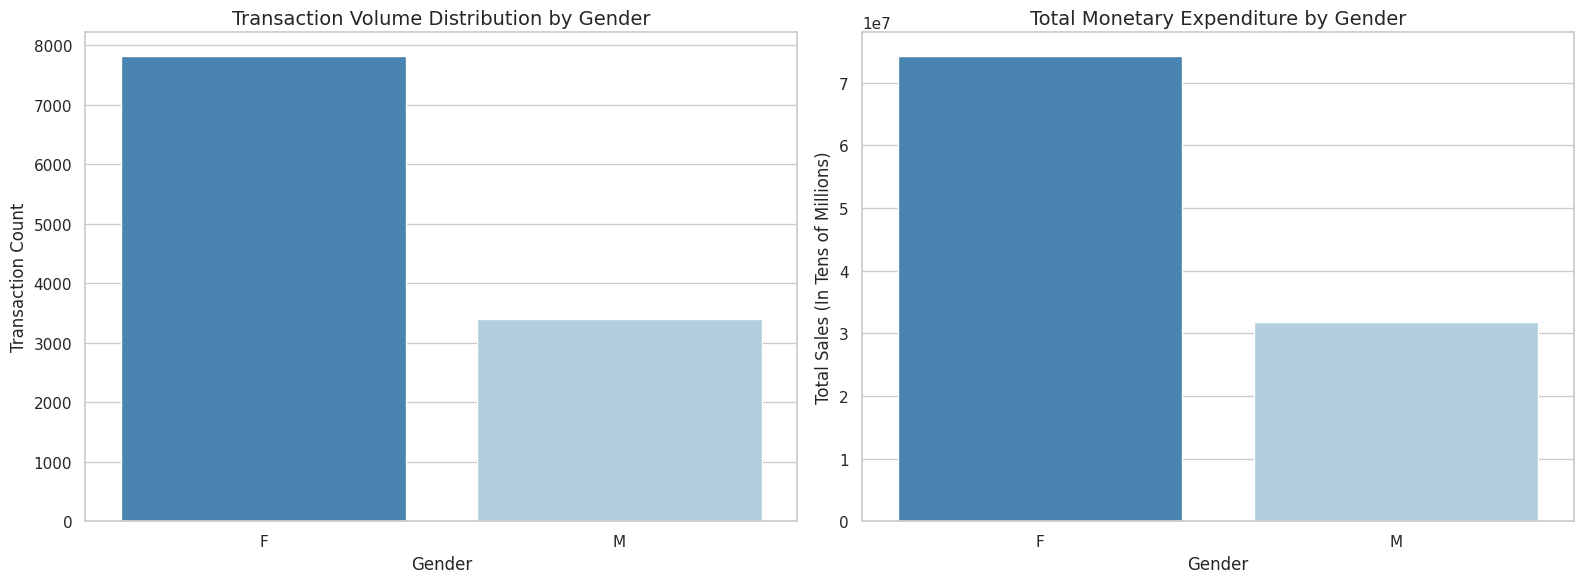

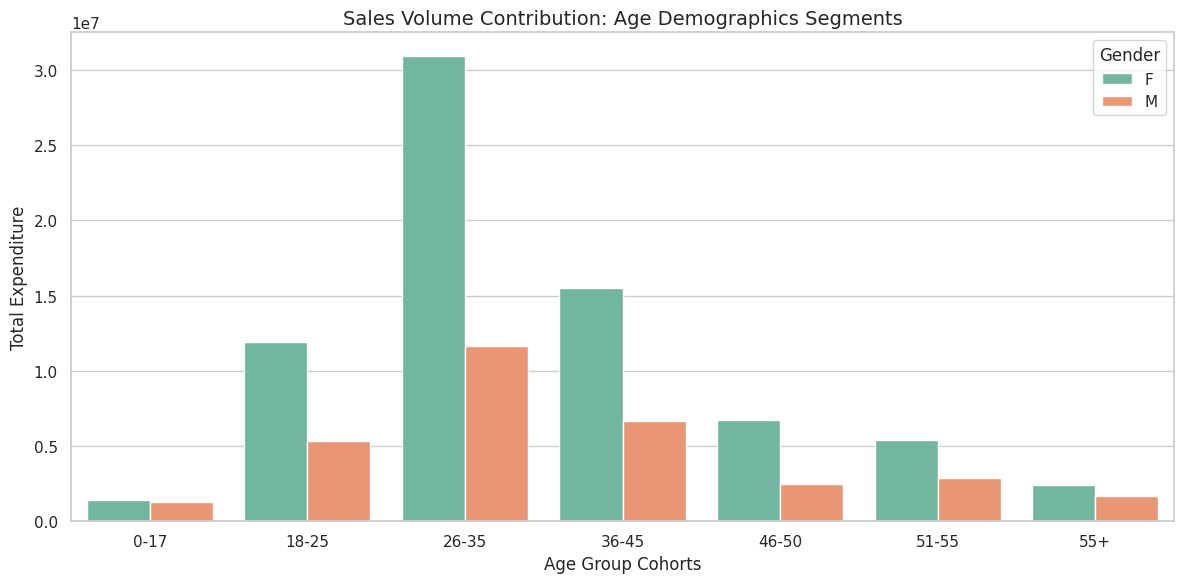

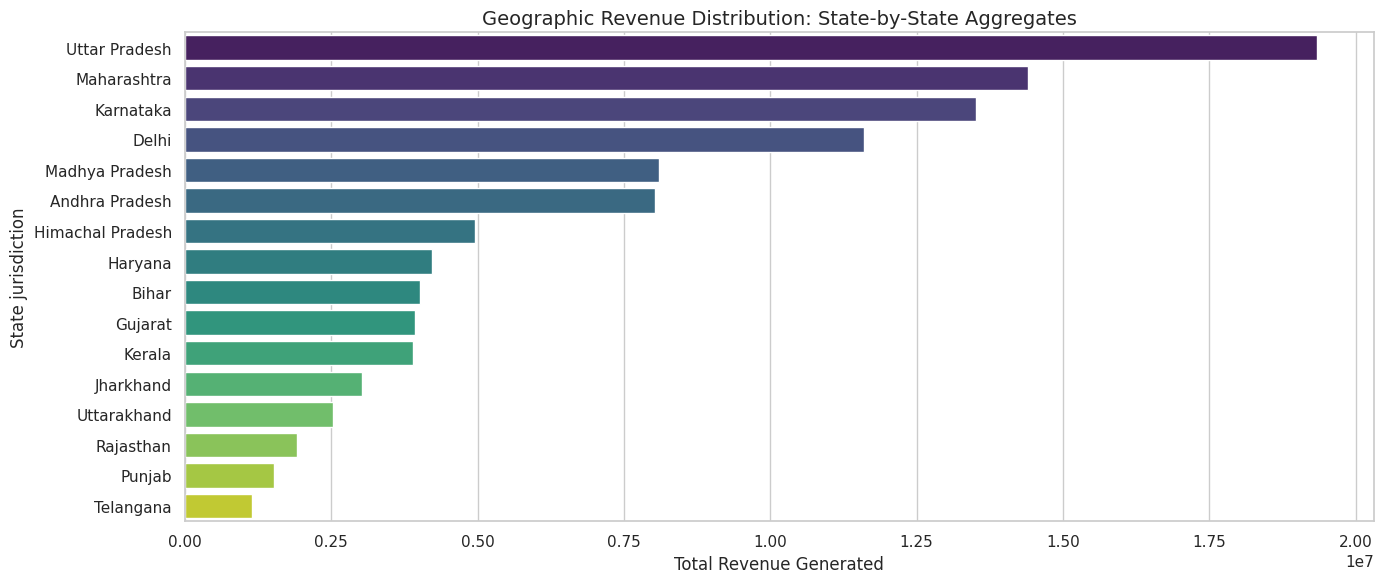

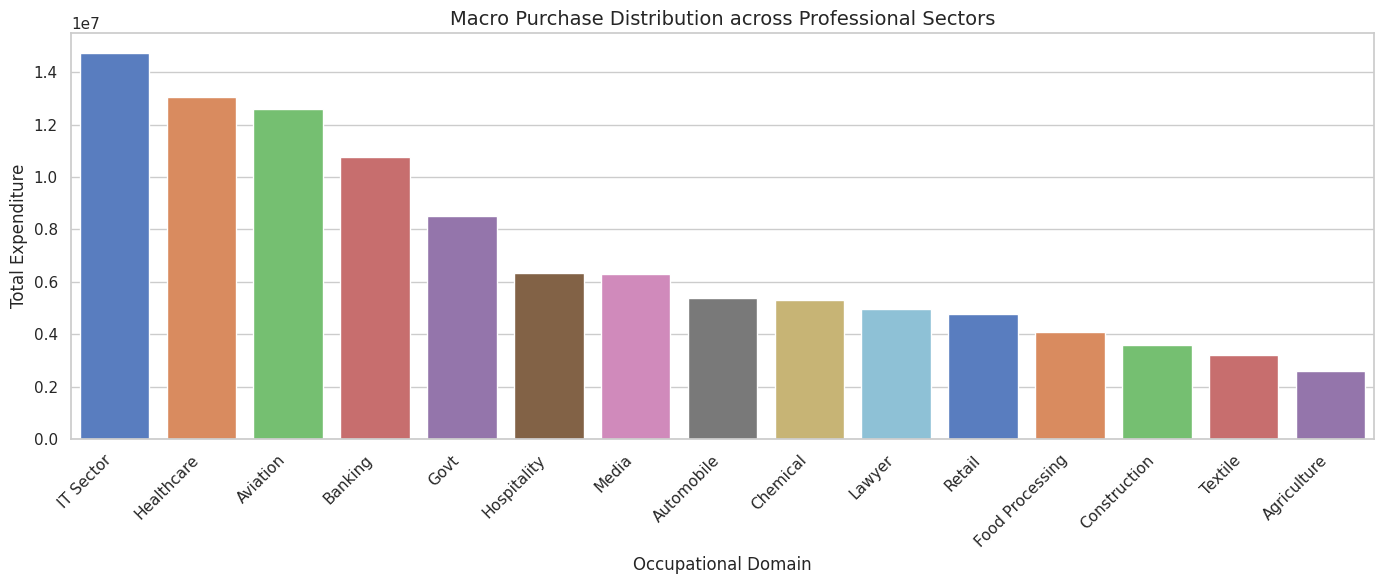

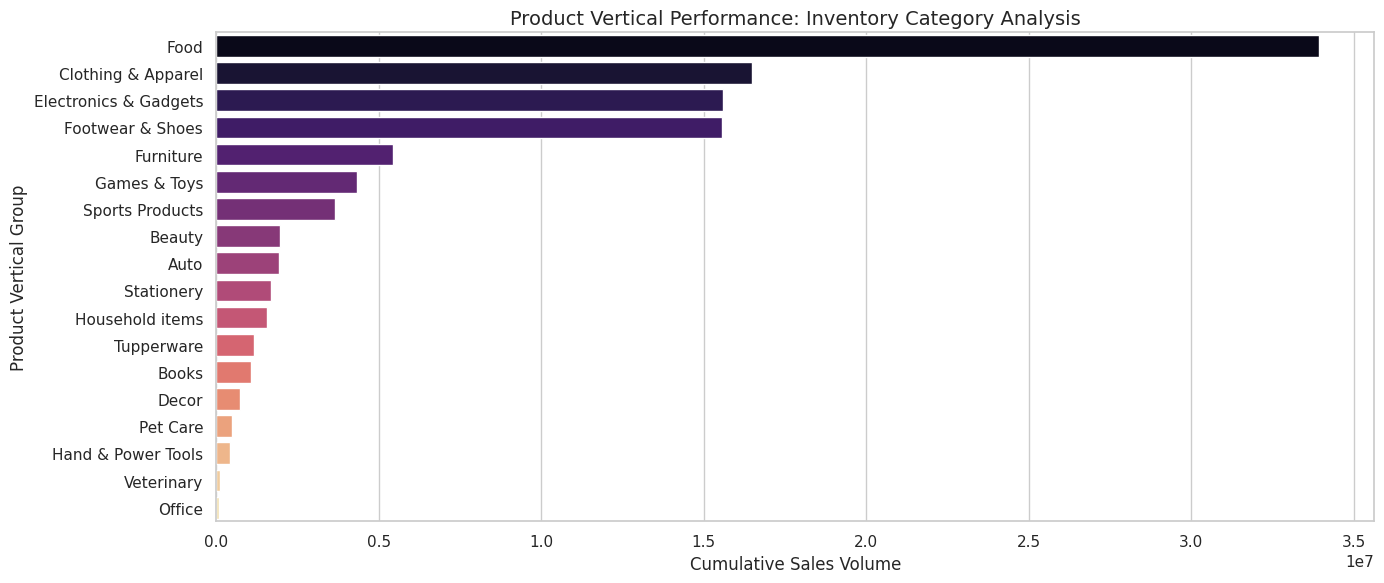

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
# Global configuration for professional presentation aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
# --
# 1. Gender-wise Purchase Volume & Value Analysis
# --
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Count plot for transaction volume
sns.countplot(x='Gender', data=df, hue='Gender', palette='Blues_r', ax=axes[0], legend=False)
axes[0].set_title('Transaction Volume Distribution by Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Transaction Count')
# Bar plot for total monetary spending
gender_spending = df.groupby(['Gender'], as_index=False)['Amount'].sum()
sns.barplot(x='Gender', y='Amount', data=gender_spending, hue='Gender', palette='Blues_r', ax=axes[1], legend=False)
axes[1].set_title('Total Monetary Expenditure by Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Total Sales (In Tens of Millions)')
plt.tight_layout()
plt.savefig('01_gender_analysis.png')
plt.show()
# --
# 2. Age Group vs Purchase Amount Analysis (Segmented by Gender)
# ---
plt.figure(figsize=(12, 6))
age_spending = df.groupby(['Age Group', 'Gender'], as_index=False)['Amount'].sum()
sns.barplot(x='Age Group', y='Amount', hue='Gender', data=age_spending, palette='Set2')
plt.title('Sales Volume Contribution: Age Demographics Segments')
plt.xlabel('Age Group Cohorts')
plt.ylabel('Total Expenditure')
plt.tight_layout()
plt.savefig('02_age_group_analysis.png')
plt.show()
# --
# 3. State-wise Revenue Contribution (Top Performing Regions)
# ---
plt.figure(figsize=(14, 6))
state_spending = df.groupby(['State'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
sns.barplot(x='Amount', y='State', data=state_spending, hue='State', palette='viridis', legend=False)
plt.title('Geographic Revenue Distribution: State-by-State Aggregates')
plt.xlabel('Total Revenue Generated')
plt.ylabel('State jurisdiction')
plt.tight_layout()
plt.savefig('03_state_sales_analysis.png')
plt.show()
# --
# 4. Industry/Occupation vs Purchase Capacity Analysis
# --
plt.figure(figsize=(14, 6))
occupation_spending = df.groupby(['Occupation'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
sns.barplot(x='Occupation', y='Amount', data=occupation_spending, hue='Occupation', palette='muted', legend=False)
plt.xticks(rotation=45, ha='right')
plt.title('Macro Purchase Distribution across Professional Sectors')
plt.xlabel('Occupational Domain')
plt.ylabel('Total Expenditure')
plt.tight_layout()
plt.savefig('04_occupation_analysis.png')
plt.show()
# --
# 5. Product Category Market Share & Popularity Analysis
# --
plt.figure(figsize=(14, 6))
product_popularity = df.groupby(['Product_Category'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
sns.barplot(x='Amount', y='Product_Category', data=product_popularity, hue='Product_Category', palette='magma', legend=False)
plt.title('Product Vertical Performance: Inventory Category Analysis')
plt.xlabel('Cumulative Sales Volume')
plt.ylabel('Product Vertical Group')
plt.tight_layout()
plt.savefig('05_product_category_analysis.png')
plt.show()